aim: make a visual inspection of the tweets dataset using the naive bayes features 

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from utils import confidence_ellipse

In [5]:
# load log likelihood table in a dataframe 
data = pd.read_csv('./data/bayes_features.csv');
data.head(5)

,positive,negative,sentiment
0,-45.763393,-63.351354,1.0
1,-105.491568,-114.204862,1.0
2,-57.028078,-67.216467,1.0
3,-10.055885,-18.589057,1.0
4,-125.749270,-138.334845,1.0


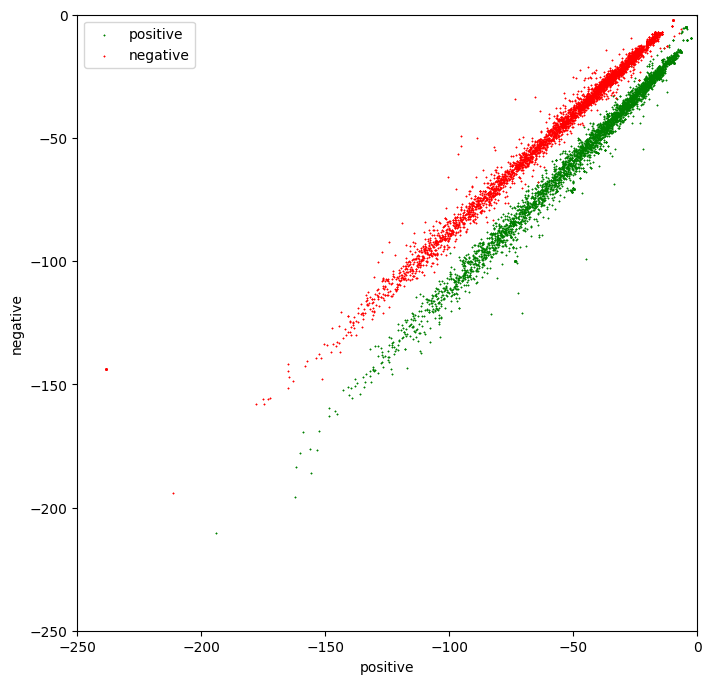

In [ ]:
# plot the samples using columns 1 and 2 of the matrix 
fig, ax = plt.subplots(figsize=(8,8))
colors = ['red', 'green']
sentiments = ['negative', 'positive']
index = data.index 

for sentiment in data.sentiment.unique():
    ix = index[data.sentiment == sentiment]
    ax.scatter(data.iloc[ix].positive, data.iloc[ix].negative, c=colors[int(sentiment)], s=0.1, marker='*', label=sentiments[int(sentiment)])

ax.legend(loc='best')
plt.xlim(-250,0)
plt.ylim(-250,0)
plt.xlabel("positive")
plt.ylabel("negative")
plt.show()

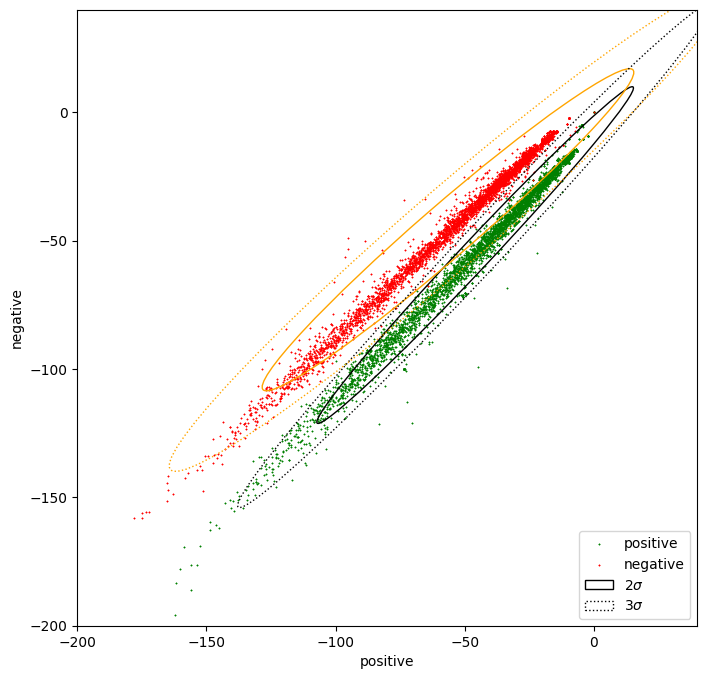

In [ ]:
# plot confidence ellipse using columns 1 and 2 of the matrix 
fig, ax = plt.subplots(figsize=(8,8))
colors = ['red', 'green'] 
sentiments = ['negative', 'positive'] 
index = data.index

for sentiment in data.sentiment.unique():
    ix = index[data.sentiment == sentiment]
    ax.scatter(data.iloc[ix].positive, data.iloc[ix].negative, c=colors[int(sentiment)], s=0.1, marker='*', label=sentiments[int(sentiment)])

plt.xlim(-200,40)  
plt.ylim(-200,40)
plt.xlabel("positive") 
plt.ylabel("negative") 

data_pos = data[data.sentiment == 1] 
data_neg = data[data.sentiment == 0]

# confidence ellipses of 2 standard deviations 
confidence_ellipse(data_pos.positive, data_pos.negative, ax, n_std=2, edgecolor='black', label=r'$2\sigma$')
confidence_ellipse(data_neg.positive, data_neg.negative, ax, n_std=2, edgecolor='orange')

# confidence ellipses of 3 standard deviations 
confidence_ellipse(data_pos.positive, data_pos.negative, ax, n_std=3, edgecolor='black', linestyle=':', label=r'$3\sigma$')
confidence_ellipse(data_neg.positive, data_neg.negative, ax, n_std=3, edgecolor='orange', linestyle=':')
ax.legend(loc='lower right')

plt.show()

In [14]:
# modify the features of the samples with positive sentiment so the two distributions overlap 
data2 = data.copy()
data2.negative[data.sentiment == 1] = data2.negative * 1.5 + 50 
data2.positive[data.sentiment == 1] = data2.positive / 1.5 - 50

/var/folders/n8/jmy3zbls2_db3b68cy_bw4pr0000gn/T/ipykernel_19906/2636428618.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  data2.negative[data.sentiment == 1] = data2.negative * 1.5 + 50
/var/folders/n8/jmy3zbls2_db3b68cy_bw4pr0000gn/T/ipykernel_19906/2636428618.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate ob

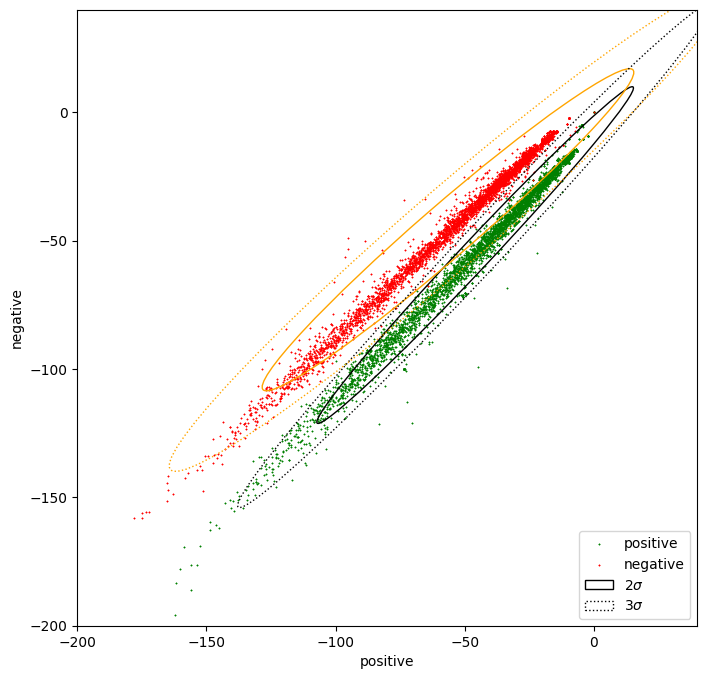

In [16]:
# plot the new confidence ellipses using columns 1 and 2 of the matrix 
fig, ax = plt.subplots(figsize=(8,8))
colors = ['red', 'green'] 
sentiments = ['negative', 'positive'] 
index = data2.index

for sentiment in data2.sentiment.unique():
    ix = index[data2.sentiment == sentiment]
    ax.scatter(data2.iloc[ix].positive, data2.iloc[ix].negative, c=colors[int(sentiment)], s=0.1, marker='*', label=sentiments[int(sentiment)])

plt.xlim(-200,40)
plt.ylim(-200,40)
plt.xlabel("positive")
plt.ylabel("negative")

data_pos = data2[data2.sentiment == 1]
data_neg = data[data2.sentiment == 0]

# confidence ellipses of 2 standard deviations
confidence_ellipse(data_pos.positive, data_pos.negative, ax, n_std=2, edgecolor='black', label=r'$2\sigma$' )
confidence_ellipse(data_neg.positive, data_neg.negative, ax, n_std=2, edgecolor='orange')

# confidence ellipses of 3 standard deviations 
confidence_ellipse(data_pos.positive, data_pos.negative, ax, n_std=3, edgecolor='black', linestyle=':', label=r'$3\sigma$')
confidence_ellipse(data_neg.positive, data_neg.negative, ax, n_std=3, edgecolor='orange', linestyle=':')
ax.legend(loc='lower right')

plt.show()